# Notebook 03 - Logistic Regression

This notebook trains Logistic Regression on the processed CICIoT2023 splits. We test the preprocessing variants, tune the model, evaluate it, and save the best run for comparison and deployment.

## 1. Imports

Load the libraries for data loading, model training, tuning, evaluation, and saving artifacts.

The code below imports sklearn's Logistic Regression, grid search tools, metrics, and joblib saving utilities.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    log_loss, recall_score, precision_score, accuracy_score
)
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline


## 2. Load Preprocessed Data

Load the feature variants and encoded labels created in Notebook 2. Keeping the variants in one dictionary makes switching experiments simple.

The code below loads each feature variant and the encoded target splits into memory.

In [65]:
DATA_DIR = Path('../data/processed')
print('Using processed folder:', DATA_DIR.resolve())


def load_csv(name, base_dir=DATA_DIR):
    path = base_dir / name
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    return pd.read_csv(path)


# --- Feature splits ---
X_train_raw        = load_csv('X_train_raw.csv')
X_val_raw          = load_csv('X_val_raw.csv')
X_test_raw         = load_csv('X_test_raw.csv')

X_train_out        = load_csv('X_train_out.csv')
X_val_out          = load_csv('X_val_out.csv')
X_test_out         = load_csv('X_test_out.csv')

X_train_scaled     = load_csv('X_train_scaled.csv')
X_val_scaled       = load_csv('X_val_scaled.csv')
X_test_scaled      = load_csv('X_test_scaled.csv')

X_train_out_scaled = load_csv('X_train_out_scaled.csv')
X_val_out_scaled   = load_csv('X_val_out_scaled.csv')
X_test_out_scaled  = load_csv('X_test_out_scaled.csv')

# --- Label splits ---
y_train_df = load_csv('y_train_encoded.csv')
y_val_df   = load_csv('y_val_encoded.csv')
y_test_df  = load_csv('y_test_encoded.csv')

for name, df in [('y_train', y_train_df), ('y_val', y_val_df), ('y_test', y_test_df)]:
    if df.shape[1] != 1:
        raise ValueError(f'{name}_encoded.csv must contain exactly one column.')

y_train = y_train_df.iloc[:, 0].to_numpy()
y_val   = y_val_df.iloc[:, 0].to_numpy()
y_test  = y_test_df.iloc[:, 0].to_numpy()

# --- Convert features to numpy ---
X_train_raw        = X_train_raw.to_numpy()
X_val_raw          = X_val_raw.to_numpy()
X_test_raw         = X_test_raw.to_numpy()

X_train_out        = X_train_out.to_numpy()
X_val_out          = X_val_out.to_numpy()
X_test_out         = X_test_out.to_numpy()

X_train_scaled     = X_train_scaled.to_numpy()
X_val_scaled       = X_val_scaled.to_numpy()
X_test_scaled      = X_test_scaled.to_numpy()

X_train_out_scaled = X_train_out_scaled.to_numpy()
X_val_out_scaled   = X_val_out_scaled.to_numpy()
X_test_out_scaled  = X_test_out_scaled.to_numpy()

# --- Organize into a dictionary ---
splits = {
    'raw':        {'X_train': X_train_raw,        'X_val': X_val_raw,        'X_test': X_test_raw},
    'out':        {'X_train': X_train_out,        'X_val': X_val_out,        'X_test': X_test_out},
    'scaled':     {'X_train': X_train_scaled,     'X_val': X_val_scaled,     'X_test': X_test_scaled},
    'out_scaled': {'X_train': X_train_out_scaled, 'X_val': X_val_out_scaled, 'X_test': X_test_out_scaled},
}

print('Data loaded successfully.')
print(f'Train: {y_train.shape[0]} samples | Val: {y_val.shape[0]} | Test: {y_test.shape[0]}')
print(f'Features: {X_train_raw.shape[1]} | Classes: {len(np.unique(y_train))}')

Using processed folder: C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\processed
Data loaded successfully.
Train: 901868 samples | Val: 193258 | Test: 193258
Features: 39 | Classes: 34


## 3. Select Feature Version

Logistic Regression is sensitive to feature scale, so scaled variants are usually the most suitable. This setting chooses which saved feature version to train on.

The code below chooses `FEATURE_VERSION` and assigns the matching train/validation/test arrays.

In [66]:
# Options: 'raw' | 'out' | 'scaled' | 'out_scaled'
FEATURE_VERSION = 'out_scaled'

X_train = splits[FEATURE_VERSION]['X_train']
X_val   = splits[FEATURE_VERSION]['X_val']
X_test  = splits[FEATURE_VERSION]['X_test']
# y arrays are identical across all variants — no change needed

print(f'Feature version selected: {FEATURE_VERSION}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_val: {y_val.shape} | y_test: {y_test.shape}')
print('\nClass distribution in y_train:')
print(pd.Series(y_train).value_counts().sort_index())
print('\nUnique classes:', np.unique(y_train))

Feature version selected: out_scaled
X_train: (901868, 39) | X_val: (193258, 39) | X_test: (193258, 39)
y_train: (901868,) | y_val: (193258,) | y_test: (193258,)

Class distribution in y_train:
0      2152
1     35000
2      3892
3      3605
4     35000
5     19318
6     35000
7     35000
8     35000
9     35000
10    15679
11    35000
12    35000
13    35000
14    35000
15    35000
16     8764
17    35000
18    35000
19    35000
20    35000
21    35000
22    35000
23    35000
24    35000
25    35000
26    35000
27    35000
28     1513
29    35000
30     3515
31      837
32    35000
33     2593
Name: count, dtype: int64

Unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33]


## 4. Class Weights and Configuration

Use the class weights from Notebook 2 to reduce the impact of class imbalance. The random seed keeps the experiment reproducible.

The code below loads class weights and sets shared configuration values like random seed and max iterations.

In [67]:
custom_class_weights = {
    '0':  12.325989503608135, '1':  0.757872268907563,  '2':  6.815398101686718,
    '3':  7.3579831932773105, '4':  0.757872268907563,  '5':  1.3730991516598356,
    '6':  0.757872268907563,  '7':  0.757872268907563,  '8':  0.757872268907563,
    '9':  0.757872268907563,  '10': 1.6917870662519743, '11': 0.757872268907563,
    '12': 0.757872268907563,  '13': 0.757872268907563,  '14': 0.757872268907563,
    '15': 0.757872268907563,  '16': 3.0266464413241336, '17': 0.757872268907563,
    '18': 0.757872268907563,  '19': 0.757872268907563,  '20': 0.757872268907563,
    '21': 0.757872268907563,  '22': 0.757872268907563,  '23': 0.757872268907563,
    '24': 0.757872268907563,  '25': 0.757872268907563,  '26': 0.757872268907563,
    '27': 0.757872268907563,  '28': 17.531744488938998, '29': 0.757872268907563,
    '30': 7.546381055978579,  '31': 31.69119404034015,  '32': 0.757872268907563,
    '33': 10.229668110977519
}
custom_class_weights = {int(k): float(v) for k, v in custom_class_weights.items()}

BENIGN_LABEL = 1  # BENIGN = class index 1 in Notebook 02's alphabetical LabelEncoder

print(f'Class weights: {len(custom_class_weights)} classes')
print(f'Min weight: {min(custom_class_weights.values()):.4f}  (majority classes)')
print(f'Max weight: {max(custom_class_weights.values()):.4f}  (rarest class)')
print(f'Benign label: {BENIGN_LABEL}')

Class weights: 34 classes
Min weight: 0.7579  (majority classes)
Max weight: 31.6912  (rarest class)
Benign label: 1


## 5. Fixed Validation Split

Use `PredefinedSplit` so grid search respects our existing train/validation split instead of reshuffling the data.

The code below combines train and validation data, then marks which rows belong to the validation fold.

In [68]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

# -1 = always in training fold, 0 = always in validation fold
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     0 * np.ones(len(X_val),   dtype=int)
])

predefined_split = PredefinedSplit(test_fold=test_fold)

print(f'X_train_val shape: {X_train_val.shape}')
print(f'Training samples   (fold = -1): {(test_fold == -1).sum()}')
print(f'Validation samples (fold =  0): {(test_fold == 0).sum()}')

X_train_val shape: (1095126, 39)
Training samples   (fold = -1): 901868
Validation samples (fold =  0): 193258


## 6. Model and Hyperparameter Grid

Define the Logistic Regression model and the values of `C` to try. `C` controls regularization strength.

The code below defines the LBFGS Logistic Regression model and the grid of `C` values to test.

In [ ]:
base_model = LogisticRegression(
    solver='lbfgs',          
    max_iter=1000,         
    class_weight=custom_class_weights,
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline([('clf', base_model)])

param_grid = {'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

print('Base model:', base_model)
print('Hyperparameter grid:', param_grid)

Base model: LogisticRegression(class_weight={0: 12.325989503608135, 1: 0.757872268907563,
                                 2: 6.815398101686718, 3: 7.3579831932773105,
                                 4: 0.757872268907563, 5: 1.3730991516598356,
                                 6: 0.757872268907563, 7: 0.757872268907563,
                                 8: 0.757872268907563, 9: 0.757872268907563,
                                 10: 1.6917870662519743, 11: 0.757872268907563,
                                 12: 0.757872268907563, 13: 0.757872268907563,
                                 14: 0.757872268907563, 15: 0.757...68907563,
                                 16: 3.0266464413241336, 17: 0.757872268907563,
                                 18: 0.757872268907563, 19: 0.757872268907563,
                                 20: 0.757872268907563, 21: 0.757872268907563,
                                 22: 0.757872268907563, 23: 0.757872268907563,
                                 24: 0.7578722

## 7. Hyperparameter Tuning

Run grid search using macro-F1. Macro-F1 is useful here because every class matters, not only the largest ones.

The code below runs grid search, reports the best setting, and keeps the best hyperparameters.

In [70]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=predefined_split,
    refit=False,
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_val, y_train_val)

results = pd.DataFrame(grid_search.cv_results_).sort_values(
    by='mean_test_score', ascending=False
)

print('\nValidation tuning results:')
print(results[['param_clf__C', 'mean_train_score', 'mean_test_score', 'rank_test_score']].to_string())

best_C = float(results.iloc[0]['param_clf__C'])
print(f'\nBest C selected from validation set: {best_C}')

Fitting 1 folds for each of 6 candidates, totalling 6 fits

Validation tuning results:
   param_clf__C  mean_train_score  mean_test_score  rank_test_score
4        10.000          0.550118         0.550116                1
5       100.000          0.549937         0.549739                2
3         1.000          0.549604         0.549588                3
2         0.100          0.547657         0.547563                4
1         0.010          0.532484         0.532488                5
0         0.001          0.515033         0.515251                6

Best C selected from validation set: 10.0


## 8. Evaluation Function

Use one function to compute the same metrics every time: accuracy, macro precision/recall/F1, benign false positive rate, and per-class recall.

The code below defines a reusable metric function for train, validation, and test evaluation.

In [ ]:
N_CLASSES  = len(np.unique(y_train))
ALL_LABELS = np.arange(N_CLASSES)


def evaluate_intrusion_model(model, X, y, benign_label, split_name='Split'):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    macro_f1  = f1_score(y, y_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    loss      = log_loss(y, y_prob, labels=ALL_LABELS)
    per_rec   = recall_score(y, y_pred, average=None, labels=ALL_LABELS, zero_division=0)
    cm        = confusion_matrix(y, y_pred, labels=ALL_LABELS)
    accuracy        = accuracy_score(y, y_pred)
    macro_precision = precision_score(y, y_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    macro_recall    = recall_score(y, y_pred, average='macro',    labels=ALL_LABELS, zero_division=0)
    benign_mask = (y == benign_label)
    benign_fpr  = np.mean(y_pred[benign_mask] != benign_label) if benign_mask.sum() > 0 else np.nan

    print(f'\n===== {split_name} =====')
    print(f'  Log Loss:   {loss:.6f}')
    print(f'  Macro-F1:   {macro_f1:.6f}')
    print(f'  Benign FPR: {benign_fpr:.6f}')
    print(f' Accuracy: {accuracy:.6f}')
    print(f' Macro-Precision: {macro_precision:.6f}')
    print(f' Macro-Recall: {macro_recall:.6f}')
    print('\n  Per-class Recall:')
    for label, rec in zip(ALL_LABELS, per_rec):
        print(f'    Class {label:2d}: {rec:.4f}')
    print('\n  Classification Report:')
    print(classification_report(y, y_pred, labels=ALL_LABELS, zero_division=0))
    print('  Confusion Matrix:')
    print(cm)

    return {
        'split': split_name, 'log_loss': loss, 'macro_f1': macro_f1,
        'benign_fpr': benign_fpr, 'per_class_recall': per_rec,
        'confusion_matrix': cm,
        'accuracy': accuracy, 'macro_recall': macro_recall,'macro_precision': macro_precision
    }

## 9. Train vs Validation Check

Train on `X_train` only and compare train vs validation scores. This helps spot underfitting or overfitting before final training.

The code below trains on training data only and prints train/validation scores for diagnosis.

===== Train =====

--- Overall metrics across all 34 classes ---
Macro Precision   : 0.5702
Macro Recall      : 0.5848
Macro F1          : 0.5497
Weighted Precision: 0.6985
Weighted Recall   : 0.6639
Weighted F1       : 0.6643
Micro Precision   : 0.6639
Micro Recall      : 0.6639
Micro F1          : 0.6639
Log Loss          : 0.9256
Benign FPR        : 0.5228

--- Per-class metrics ---
 label  precision   recall       f1
     0   0.026682 0.096190 0.041776
     1   0.449148 0.477200 0.462749
     2   0.085794 0.349435 0.137763
     3   0.131815 0.219972 0.164848
     4   0.997109 0.985343 0.991191
     5   0.746786 0.718604 0.732424
     6   0.998796 0.995743 0.997267
     7   0.993392 0.983600 0.988472
     8   0.992780 0.997914 0.995341
     9   0.999828 0.997143 0.998484
    10   0.777346 0.905606 0.836589
    11   0.450761 0.835686 0.585636
    12   0.478425 0.253429 0.331341
    13   0.584556 0.621400 0.602415
    14   0.645058 0.837286 0.728708
    15   0.990712 0.984371 0.987532

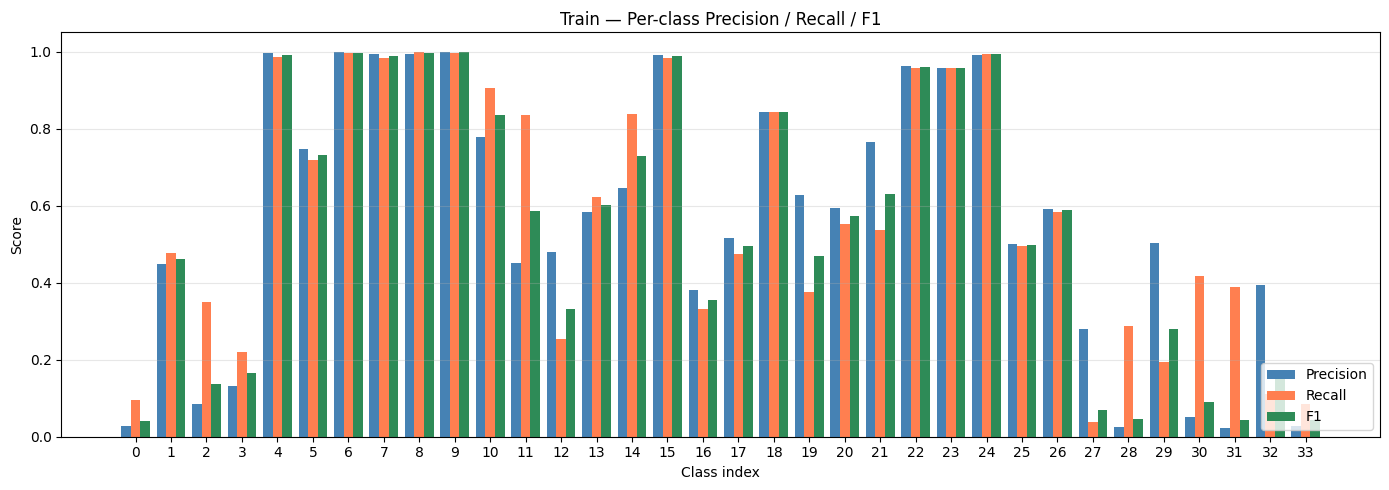

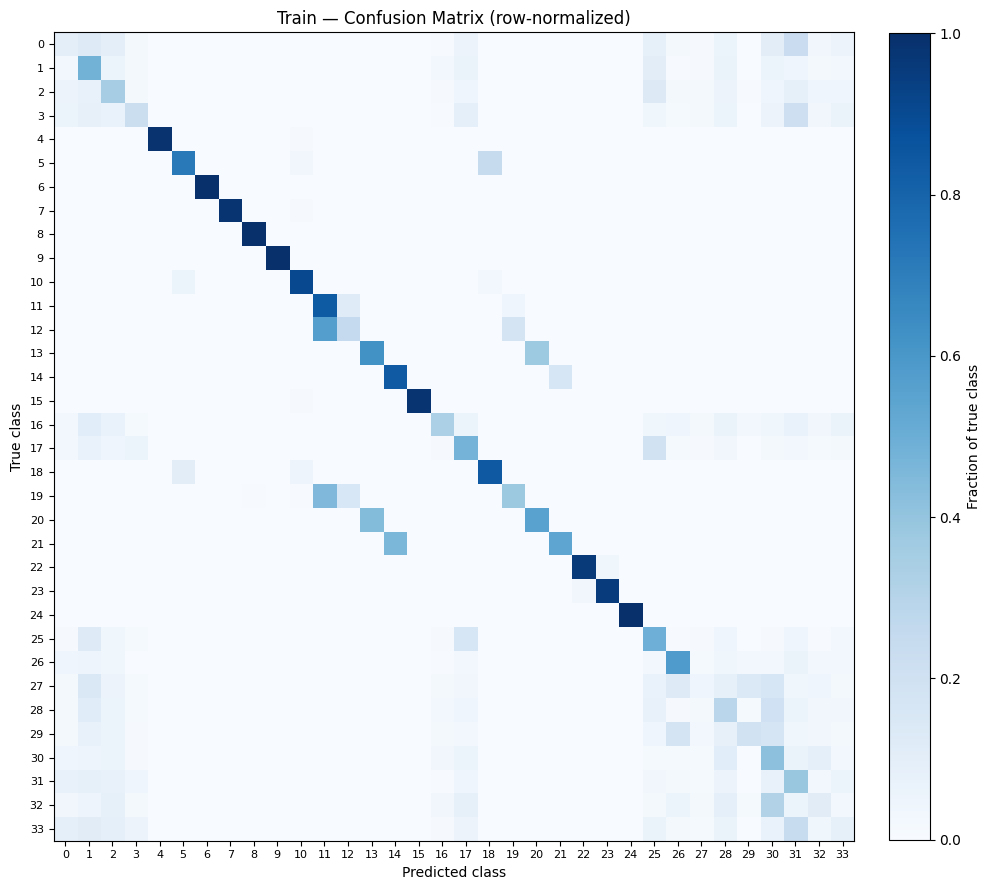

===== Validation =====

--- Overall metrics across all 34 classes ---
Macro Precision   : 0.5700
Macro Recall      : 0.5825
Macro F1          : 0.5494
Weighted Precision: 0.6978
Weighted Recall   : 0.6631
Weighted F1       : 0.6637
Micro Precision   : 0.6631
Micro Recall      : 0.6631
Micro F1          : 0.6631
Log Loss          : 0.9265
Benign FPR        : 0.5224

--- Per-class metrics ---
 label  precision   recall       f1
     0   0.026627 0.097614 0.041841
     1   0.460411 0.477600 0.468848
     2   0.092833 0.368106 0.148273
     3   0.129310 0.213454 0.161054
     4   0.996083 0.983200 0.989599
     5   0.754082 0.725296 0.739409
     6   0.998130 0.996533 0.997331
     7   0.993143 0.984933 0.989021
     8   0.992180 0.998133 0.995148
     9   0.999465 0.996133 0.997796
    10   0.776184 0.902083 0.834412
    11   0.449664 0.830800 0.583509
    12   0.474901 0.254800 0.331656
    13   0.583846 0.619733 0.601255
    14   0.642128 0.838533 0.727304
    15   0.992336 0.984000 0.9

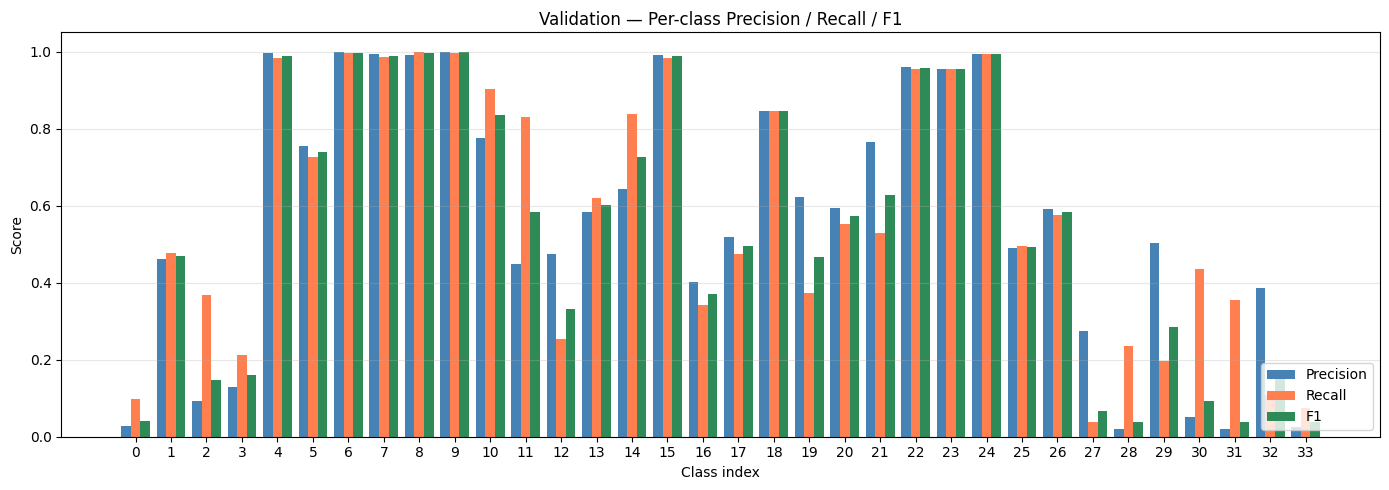

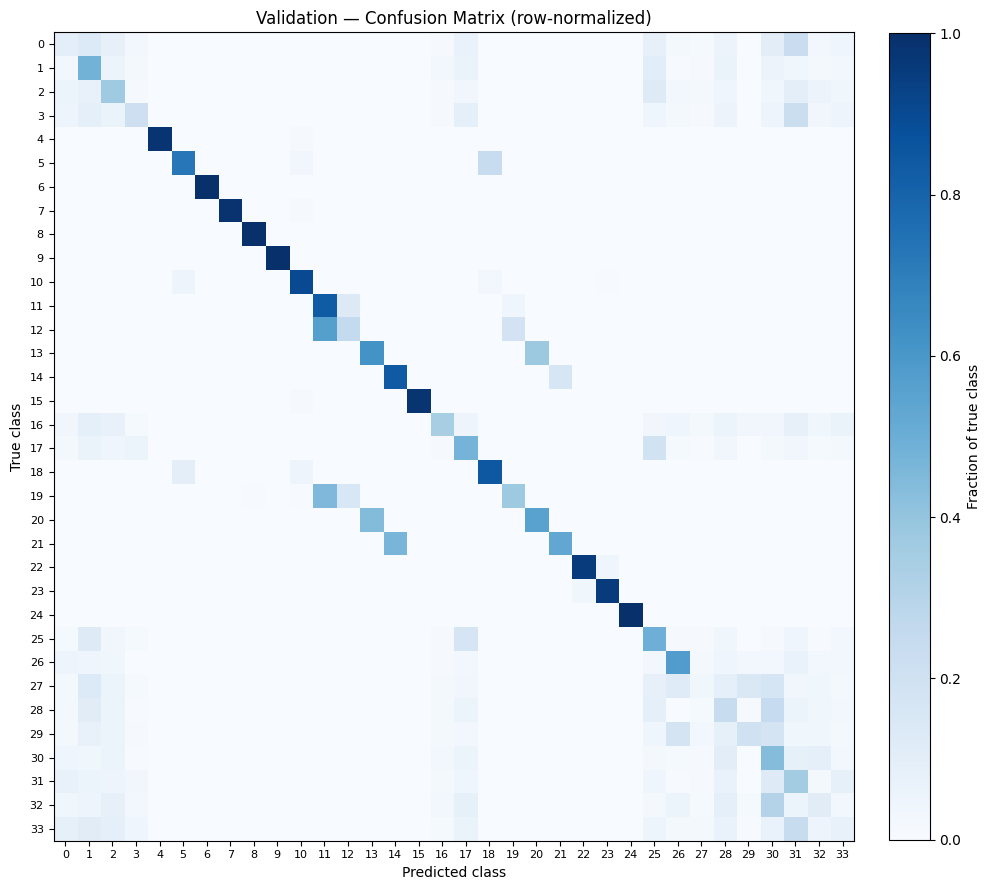

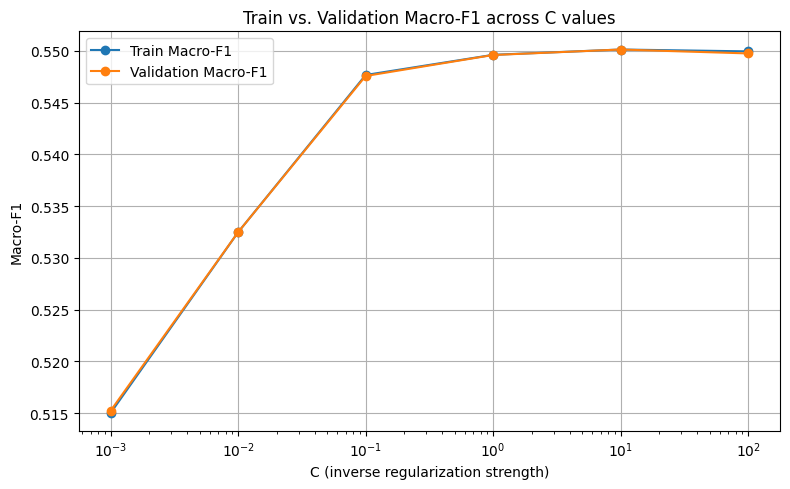

In [72]:
best_model_train_only = LogisticRegression(
    solver='lbfgs',
    C=best_C,
    max_iter=1000,
    class_weight=custom_class_weights,
    random_state=42
)
best_model_train_only.fit(X_train, y_train)

train_metrics = evaluate_intrusion_model(
    best_model_train_only, X_train, y_train, BENIGN_LABEL, 'Train'
)
val_metrics = evaluate_intrusion_model(
    best_model_train_only, X_val, y_val, BENIGN_LABEL, 'Validation'
)

# --- C vs. Macro-F1 regularization curve ---
plot_df = results.sort_values('param_clf__C')
plt.figure(figsize=(8, 5))
plt.plot(plot_df['param_clf__C'].astype(float), plot_df['mean_train_score'],
         marker='o', label='Train Macro-F1')
plt.plot(plot_df['param_clf__C'].astype(float), plot_df['mean_test_score'],
         marker='o', label='Validation Macro-F1')
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Macro-F1')
plt.title('Train vs. Validation Macro-F1 across C values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Final Model

Retrain the selected model on train plus validation data, then evaluate once on the test set. The test score is the final unbiased result for this run.

The code below retrains on train+validation and evaluates the final model on the test set.

Iterations used: 720 / 1000
Model converged successfully.
===== Final Test (retrained on train+val) =====

--- Overall metrics across all 34 classes ---
Macro Precision   : 0.5710
Macro Recall      : 0.5843
Macro F1          : 0.5502
Weighted Precision: 0.6994
Weighted Recall   : 0.6636
Weighted F1       : 0.6647
Micro Precision   : 0.6636
Micro Recall      : 0.6636
Micro F1          : 0.6636
Log Loss          : 0.9302
Benign FPR        : 0.5293

--- Per-class metrics ---
 label  precision   recall       f1
     0   0.033715 0.108225 0.051414
     1   0.450657 0.470667 0.460445
     2   0.084376 0.347722 0.135800
     3   0.137566 0.235751 0.173747
     4   0.997697 0.982000 0.989786
     5   0.738657 0.703865 0.720841
     6   0.998261 0.995200 0.996728
     7   0.992477 0.985067 0.988758
     8   0.993754 0.997067 0.995408
     9   0.999599 0.996800 0.998197
    10   0.768976 0.898512 0.828713
    11   0.448427 0.819067 0.579556
    12   0.475633 0.265467 0.340750
    13   0.594308 0

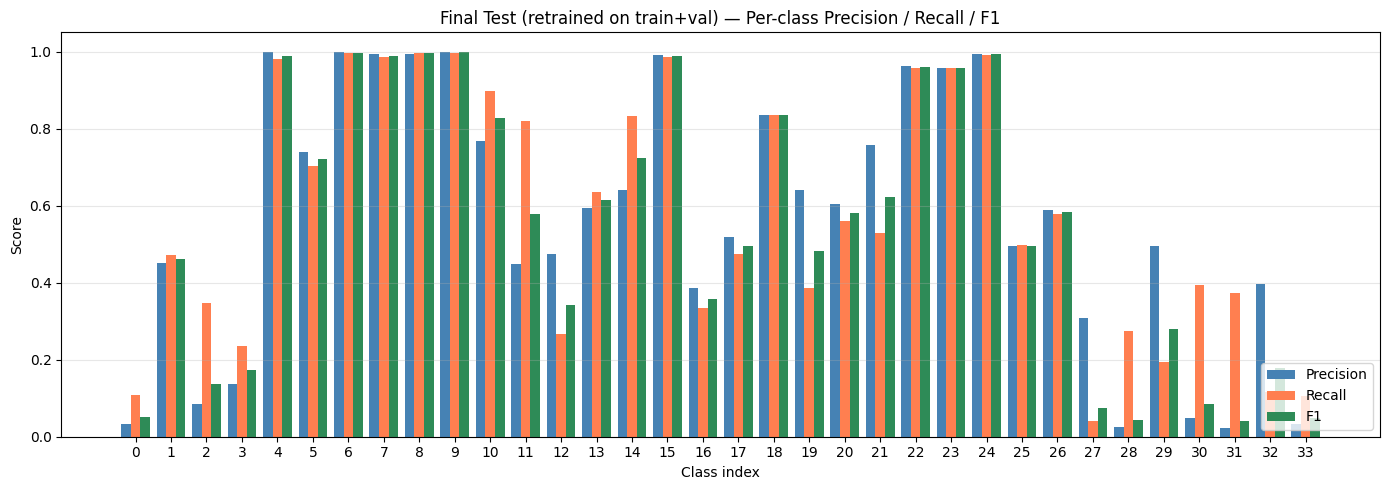

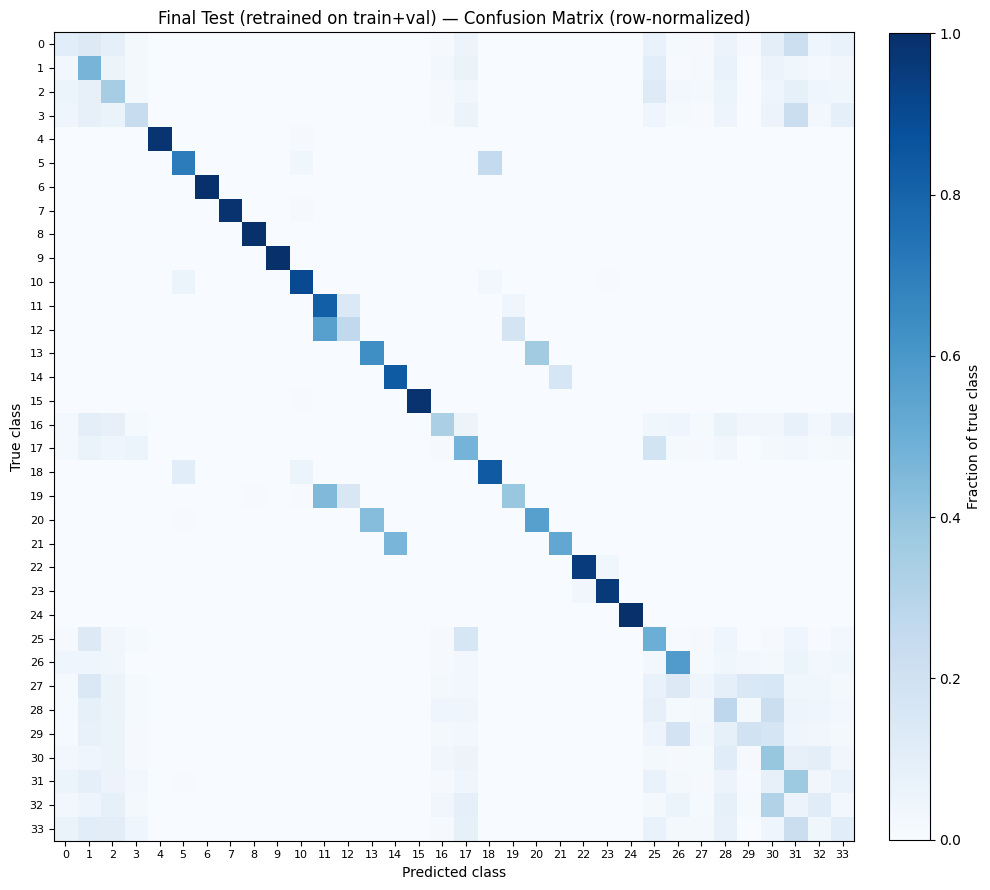

In [73]:
final_model = LogisticRegression(
    solver='lbfgs',
    C=best_C,
    max_iter=1000,
    class_weight=custom_class_weights,
    random_state=42
)

final_model.fit(X_train_val, y_train_val)

# Convergence check
print(f'Iterations used: {final_model.n_iter_.max()} / {final_model.max_iter}')
if final_model.n_iter_.max() >= final_model.max_iter:
    print('WARNING: model may not have fully converged — consider increasing max_iter.')
else:
    print('Model converged successfully.')

final_test_metrics = evaluate_intrusion_model(
    final_model, X_test, y_test, BENIGN_LABEL,
    'Final Test (retrained on train+val)'
)

## 11. Save Final Model

Save the trained model with `joblib`. The filename includes the preprocessing variant so we know exactly how it was trained.

The code below saves the fitted model file under `data/artifacts/LR/`.

In [74]:
save_dir  = Path('../data/artifacts/LR')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / f'logistic_regression_{FEATURE_VERSION}.joblib'
joblib.dump(final_model, save_path)
print(f'Saved final model to: {save_path}')

Saved final model to: ..\data\artifacts\logistic_regression_out_scaled.joblib


## 12. Save Metrics

Write the run metrics to JSON. This makes it easy to compare variants later without rerunning training.

The code below writes the main metrics, per-class recall, and confusion matrix to disk.

In [ ]:
import json

metrics_record = {
    'model':                'logistic_regression',
    'variant':              FEATURE_VERSION,
    'best_params':          {'C': best_C},
    'n_iter':               int(final_model.n_iter_.max()),
    'n_classes':            int(N_CLASSES),
    'benign_label':         int(BENIGN_LABEL),
    'train_macro_f1':       float(train_metrics['macro_f1']),
    'val_macro_f1':         float(val_metrics['macro_f1']),
    'test_macro_f1':        float(final_test_metrics['macro_f1']),
    'train_log_loss':       float(train_metrics['log_loss']),
    'val_log_loss':         float(val_metrics['log_loss']),
    'test_log_loss':        float(final_test_metrics['log_loss']),
    'test_benign_fpr':      float(final_test_metrics['benign_fpr']),
    'test_per_class_recall': final_test_metrics['per_class_recall'].tolist(),
    'test_accuracy':        float(final_test_metrics['accuracy']),
    'test_macro_precision': float(final_test_metrics['macro_precision']),
    'test_macro_recall':    float(final_test_metrics['macro_recall'])
}

metrics_path = save_dir / f'lr_metrics_{FEATURE_VERSION}.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_record, f, indent=2)

cm_path = save_dir / f'lr_cm_{FEATURE_VERSION}.npy'
np.save(cm_path, final_test_metrics['confusion_matrix'])

print(f'Saved metrics to:          {metrics_path}')
print(f'Saved confusion matrix to: {cm_path}')

Saved metrics to:          ..\data\artifacts\lr_metrics_out_scaled.json
Saved confusion matrix to: ..\data\artifacts\lr_cm_out_scaled.npy


## 13. Compare Variants

Load all saved Logistic Regression metric files and build a comparison table. Re-run this after training another variant.

The code below loads all saved Logistic Regression runs and creates a comparison table.

In [ ]:
variant_files = sorted(save_dir.glob('lr_metrics_*.json'))

if not variant_files:
    print('No metrics files found yet. Re-run the notebook with a FEATURE_VERSION to populate this table.')
else:
    rows = []
    for f in variant_files:
        rec = json.loads(f.read_text())
        rows.append({
            'variant':         rec['variant'],
            'best_C':          rec['best_params']['C'],
            'train_f1':        rec['train_macro_f1'],
            'val_f1':          rec['val_macro_f1'],
            'test_f1':         rec['test_macro_f1'],
            'train_val_gap':   rec['train_macro_f1'] - rec['val_macro_f1'],
            'test_benign_fpr': rec['test_benign_fpr'],
            'test_log_loss':   rec['test_log_loss'],
            'n_iter':          rec['n_iter'],
            'test_accuracy': rec.get('test_accuracy'),
            'test_macro_precision': rec.get('test_macro_precision'),
            'test_macro_recall': rec.get('test_macro_recall')
        })

    comp = pd.DataFrame(rows).sort_values('test_f1', ascending=False).reset_index(drop=True)
    print(f'Comparing {len(comp)} variant(s) of Logistic Regression:\n')
    print(comp.to_string(index=False))

    comp_path = save_dir / 'lr_comparison.csv'
    comp.to_csv(comp_path, index=False)
    print(f'\nSaved comparison table to: {comp_path}')

Comparing 4 variant(s) of Logistic Regression:

   variant  best_C  train_f1   val_f1  test_f1  train_val_gap  test_benign_fpr  test_log_loss  n_iter
out_scaled  10.000  0.549702 0.549353 0.550212       0.000350         0.529333       0.930222     720
    scaled 100.000  0.540830 0.541117 0.539305      -0.000287         0.579067       0.958113     763
       out   0.001  0.207146 0.206208 0.184489       0.000938         0.650267       2.256543    1000
       raw   0.001  0.111240 0.111395 0.110672      -0.000155         0.669867       2.495562    1000

Saved comparison table to: ..\data\artifacts\lr_comparison.csv
